## Import Libiraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder,_encoders,_target_encoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import L1, L2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import to_categorical
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight
plt.rcParams['figure.figsize'] = (12,6)

## Read Data

In [21]:
df_train=pd.read_csv("/content/train (1).csv")
df_test=pd.read_csv("/content/test (1).csv")
df_train

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,Clay,6.54,13.45,1.15,1.86,26.65,26.86,1041.33,10.62,...,Rice,Sowing,Kharif,Sprinkler,River,4.35,No,118.36,South,Medium
629996,629996,Clay,7.03,54.49,0.96,2.35,36.99,88.00,1419.57,9.93,...,Sugarcane,Vegetative,Kharif,Drip,Groundwater,12.97,Yes,40.75,Central,Medium
629997,629997,Clay,6.52,11.98,0.93,0.38,37.82,70.98,88.45,8.19,...,Potato,Vegetative,Zaid,Canal,Reservoir,13.58,Yes,2.62,South,High
629998,629998,Clay,5.93,42.86,0.33,3.39,34.99,94.58,2433.92,9.88,...,Sugarcane,Vegetative,Zaid,Sprinkler,Groundwater,0.79,Yes,90.00,East,Low


## EDA

In [22]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

## Preprocessing

In [23]:
df_train.drop(['id'],axis=1,inplace=True)
sub=df_test[['id']]
df_test.drop(['id'],axis=1,inplace=True)

In [24]:
df_train.duplicated().sum()

np.int64(0)

In [25]:
cat_cols=df_train.select_dtypes(include=['object']).columns
numerical_cols=df_train.select_dtypes(include=['int64','float64']).columns
numerical_cols

Index(['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
       'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
       'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm'],
      dtype='object')

In [26]:
for i in cat_cols :
    col_name= i
    print(f'{col_name} unique value is:\n {df_train[i].unique()}')

Soil_Type unique value is:
 ['Loamy' 'Clay' 'Sandy' 'Silt']
Crop_Type unique value is:
 ['Sugarcane' 'Wheat' 'Rice' 'Potato' 'Cotton' 'Maize']
Crop_Growth_Stage unique value is:
 ['Sowing' 'Vegetative' 'Flowering' 'Harvest']
Season unique value is:
 ['Zaid' 'Kharif' 'Rabi']
Irrigation_Type unique value is:
 ['Drip' 'Rainfed' 'Sprinkler' 'Canal']
Water_Source unique value is:
 ['Rainwater' 'River' 'Reservoir' 'Groundwater']
Mulching_Used unique value is:
 ['No' 'Yes']
Region unique value is:
 ['East' 'South' 'North' 'West' 'Central']
Irrigation_Need unique value is:
 ['Low' 'Medium' 'High']


In [27]:
df_train.describe(include='object').T

,count,unique,top,freq
Soil_Type,630000,4,Sandy,166509
Crop_Type,630000,6,Sugarcane,108910
Crop_Growth_Stage,630000,4,Harvest,167689
Season,630000,3,Kharif,216561
Irrigation_Type,630000,4,Canal,161901
Water_Source,630000,4,Reservoir,162994
Mulching_Used,630000,2,No,316453
Region,630000,5,South,134809
Irrigation_Need,630000,3,Low,369917


In [28]:
mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df_train['Irrigation_Need'] = df_train['Irrigation_Need'].map(mapping)


In [29]:
df_train.tail()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
629995,Clay,6.54,13.45,1.15,1.86,26.65,26.86,1041.33,10.62,18.85,Rice,Sowing,Kharif,Sprinkler,River,4.35,No,118.36,South,1
629996,Clay,7.03,54.49,0.96,2.35,36.99,88.00,1419.57,9.93,17.99,Sugarcane,Vegetative,Kharif,Drip,Groundwater,12.97,Yes,40.75,Central,1
629997,Clay,6.52,11.98,0.93,0.38,37.82,70.98,88.45,8.19,17.25,Potato,Vegetative,Zaid,Canal,Reservoir,13.58,Yes,2.62,South,2
629998,Clay,5.93,42.86,0.33,3.39,34.99,94.58,2433.92,9.88,5.00,Sugarcane,Vegetative,Zaid,Sprinkler,Groundwater,0.79,Yes,90.00,East,0
629999,Loamy,7.02,35.36,1.19,0.46,26.92,64.33,1269.55,7.91,2.72,Maize,Harvest,Kharif,Drip,Reservoir,3.80,No,112.93,West,0


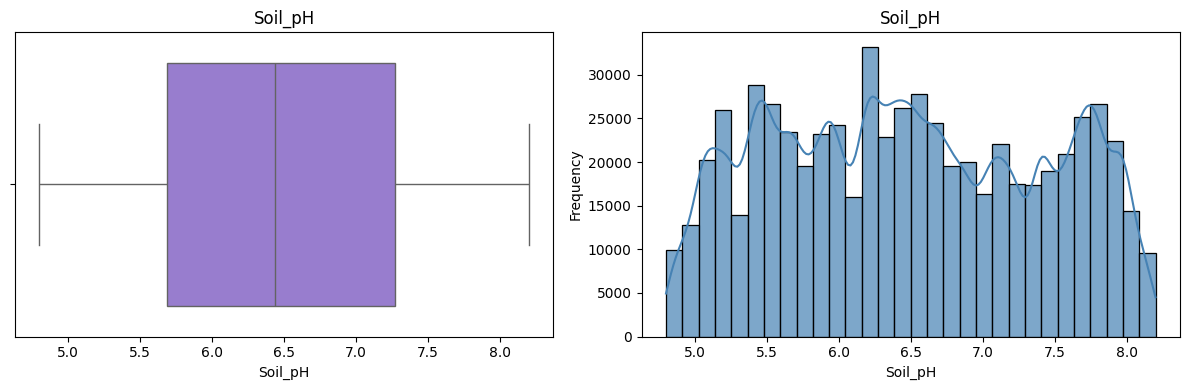

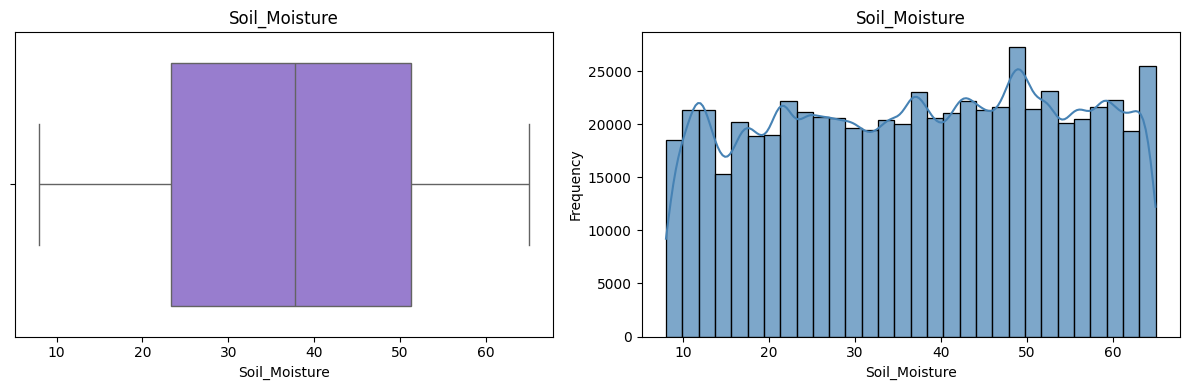

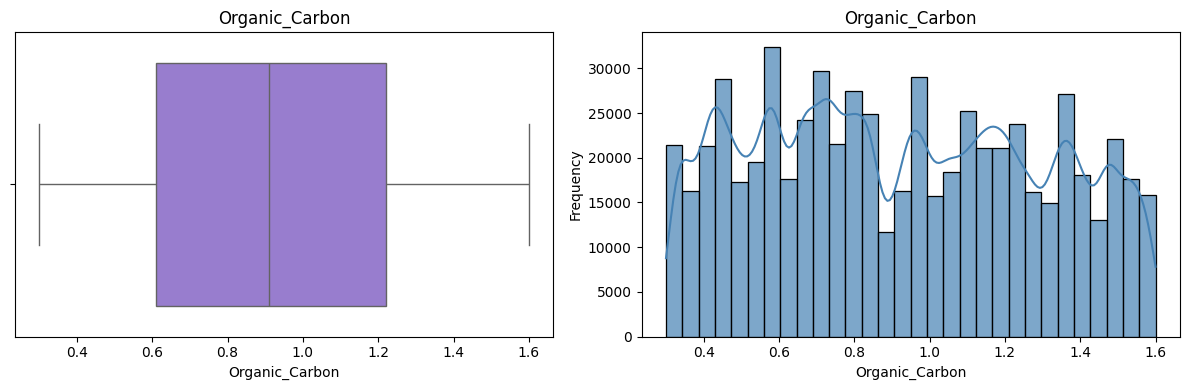

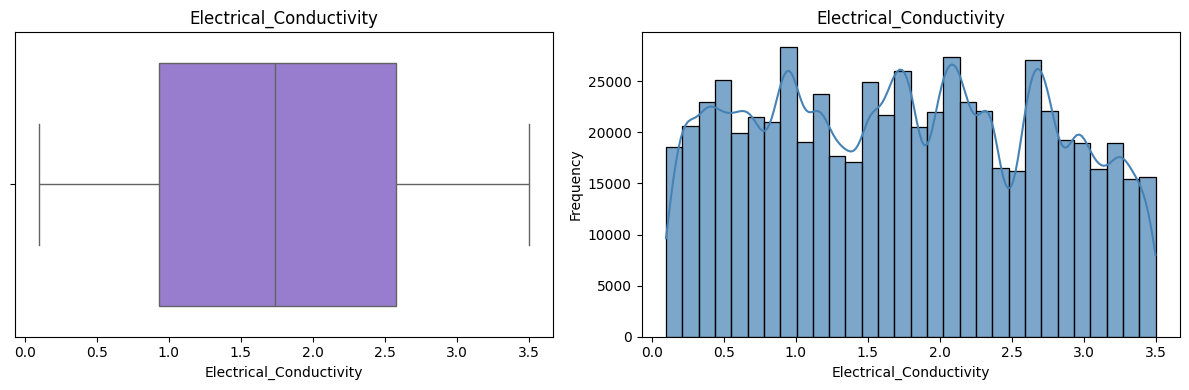

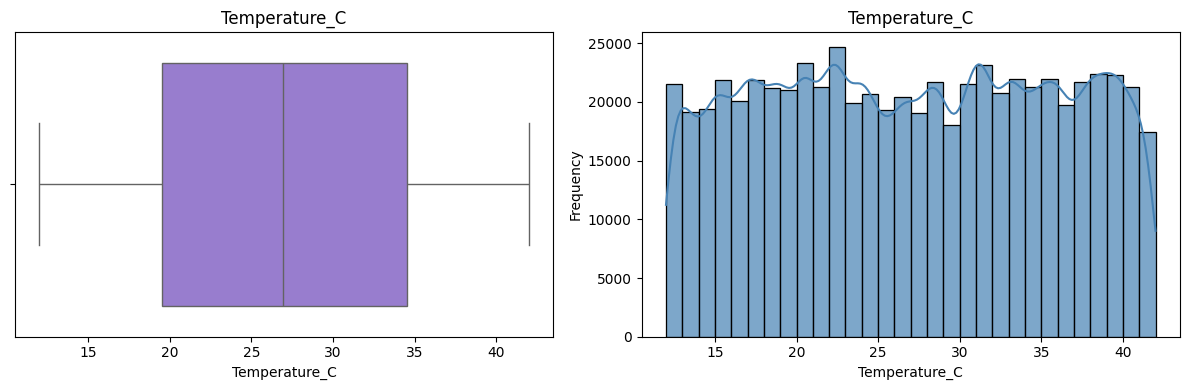

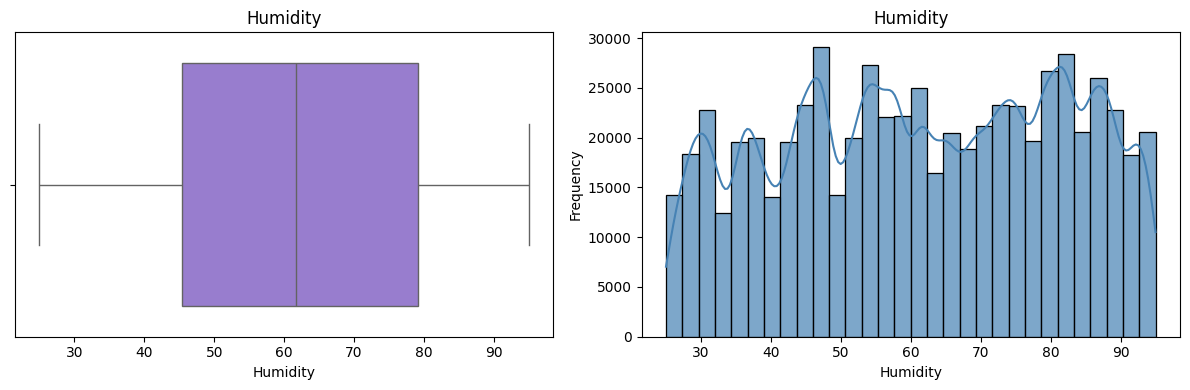

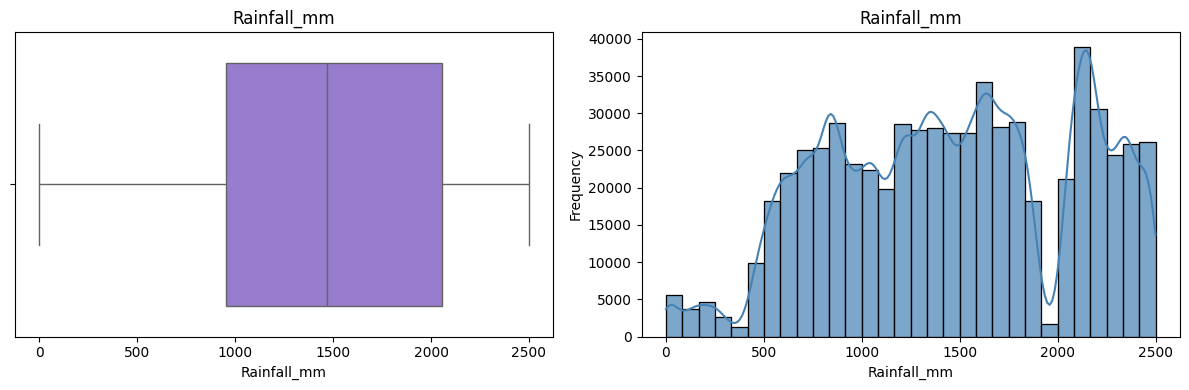

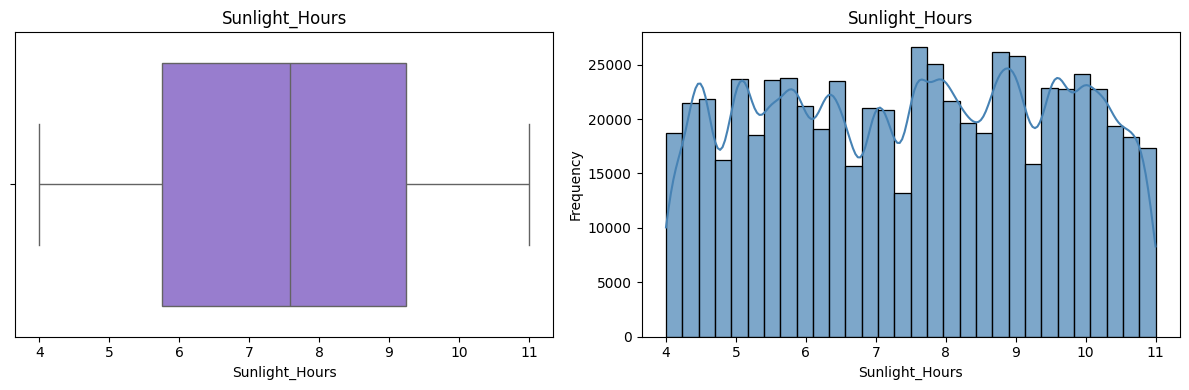

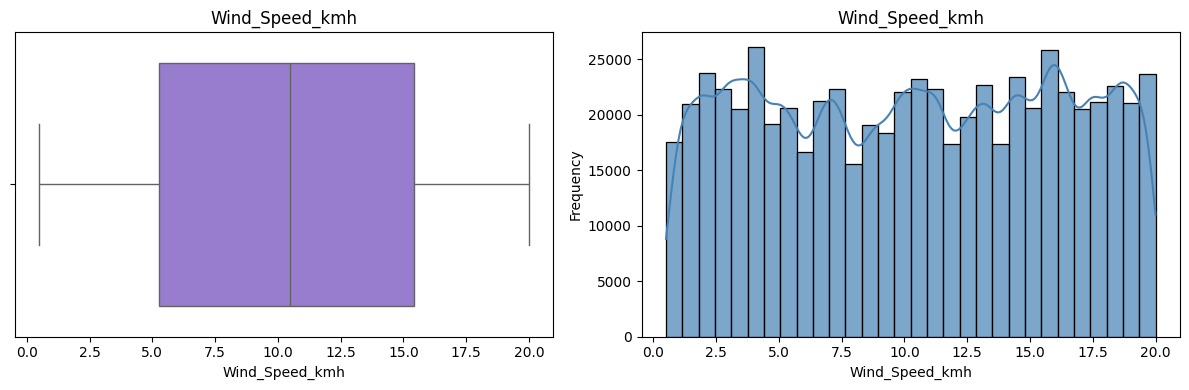

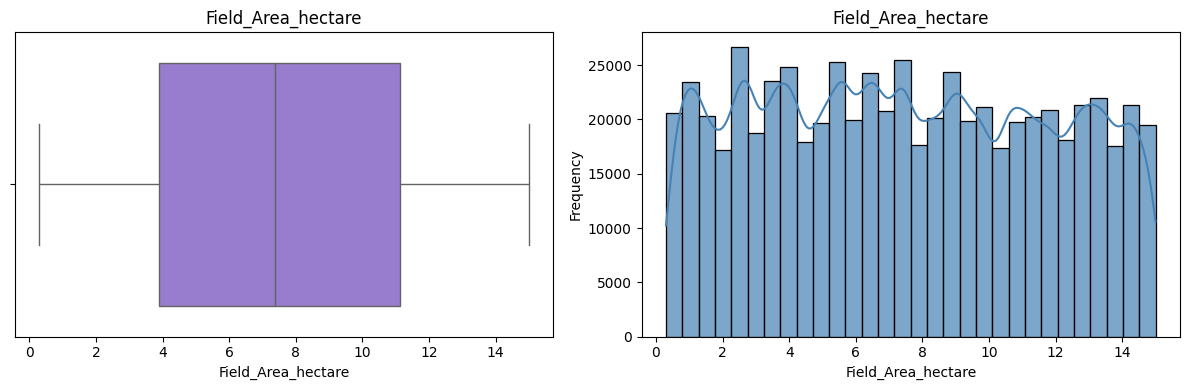

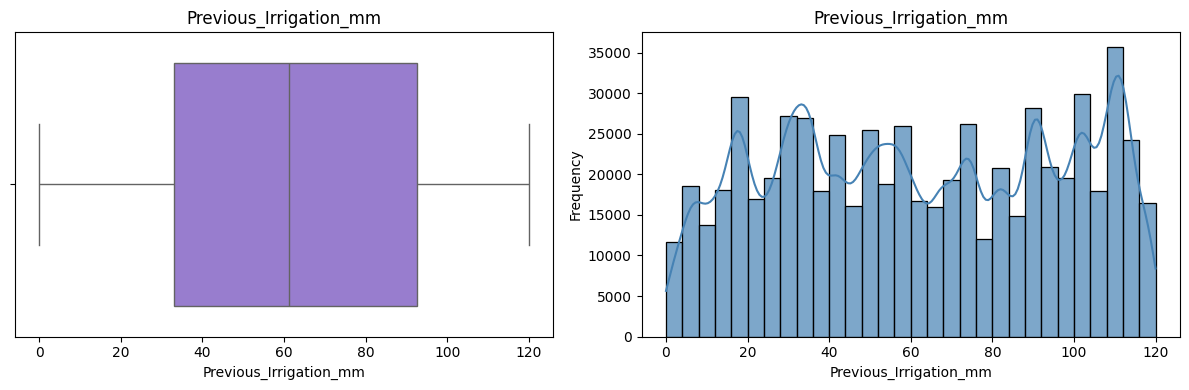

In [30]:
for col in numerical_cols:

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    sns.boxplot(x=df_train[col], ax=ax1, color='#9370DB')

    ax1.set_title(f'{col}')
    ax1.set_xlabel(col)

    sns.histplot(df_train[col], bins=30, ax=ax2, kde=True,
                 color='steelblue', edgecolor='black', alpha=0.7)

    ax2.set_title(f'{col}')
    ax2.set_xlabel(col)
    ax2.set_ylabel('Frequency')

    plt.tight_layout()

plt.show()

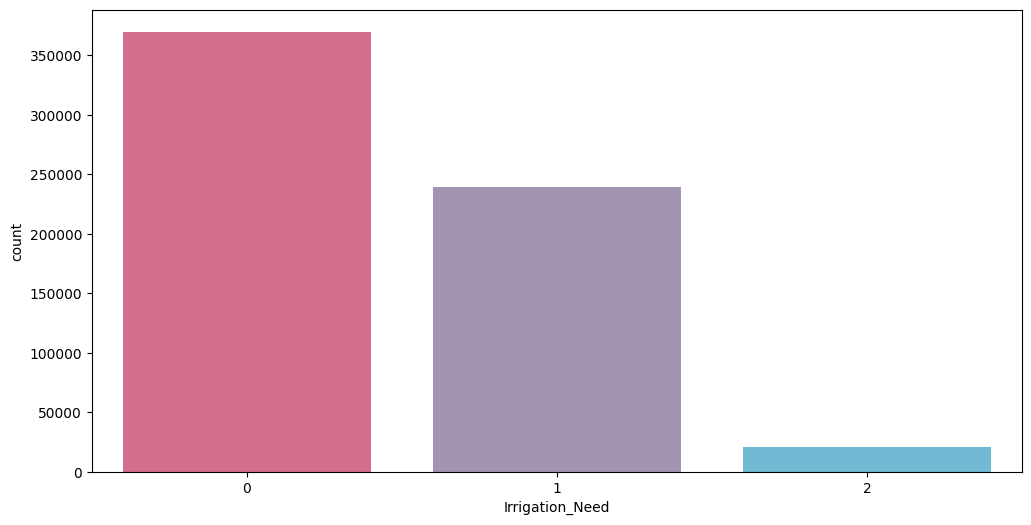

In [31]:
sns.countplot(x=df_train['Irrigation_Need'],data=df_train,palette="blend:#e55d87,#5fc3e4")
plt.show()

In [32]:
count= df_train['Irrigation_Need'].value_counts()
percent= (df_train['Irrigation_Need'].value_counts()/len(df_train))*100
summary=pd.DataFrame({
    'count': count,
    'percent': percent
})
summary

,count,percent
Irrigation_Need,,
0,369917,58.716984
1,239074,37.948254
2,21009,3.334762


## Feature Engineering

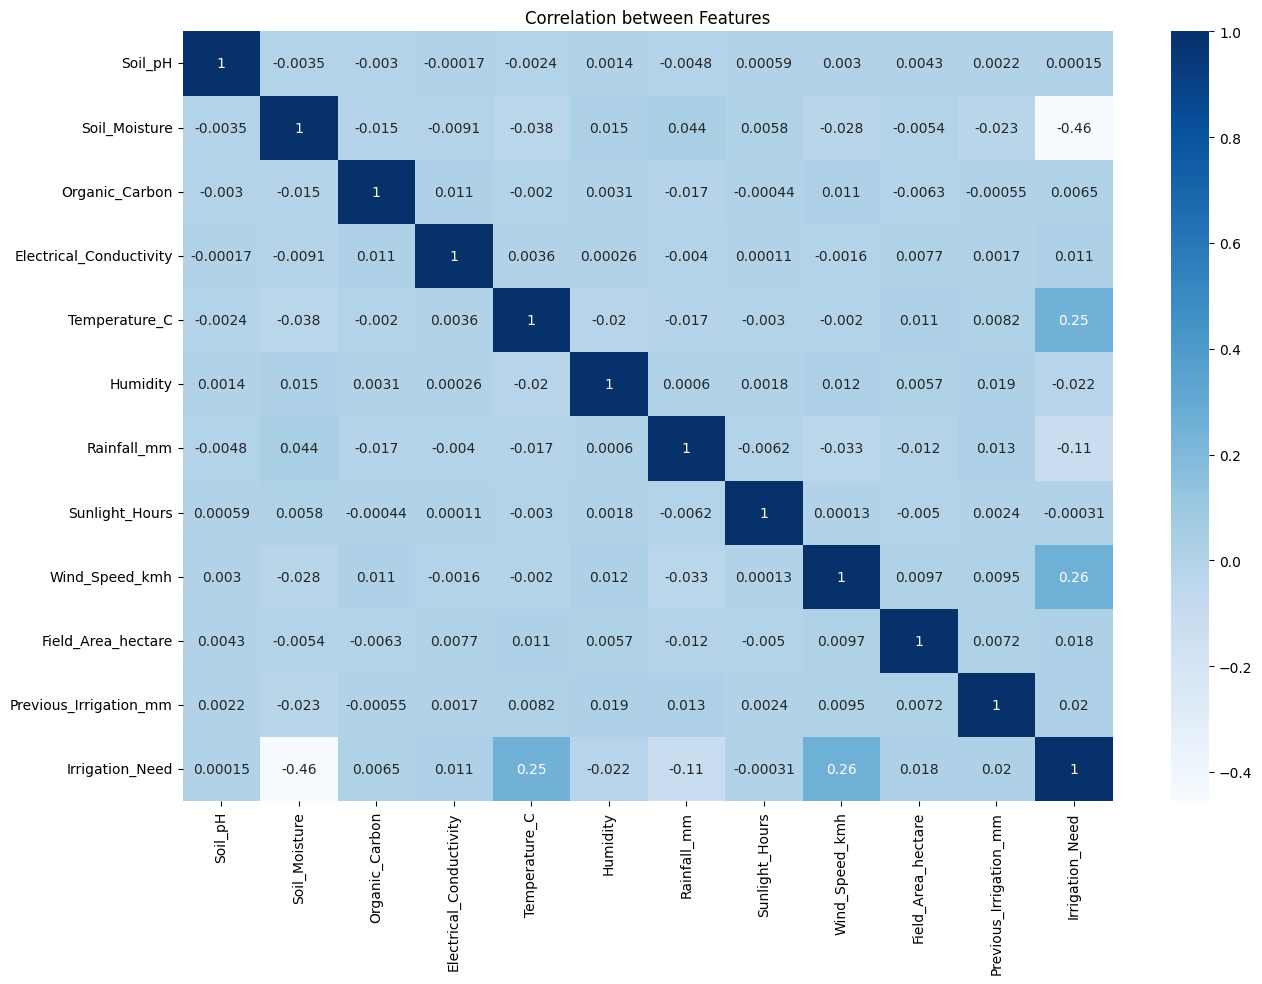

In [33]:
plt.figure(figsize=(15,10))
sns.heatmap(df_train.corr(numeric_only=True),annot=True, cmap='Blues')
plt.title("Correlation between Features")
plt.show()

In [35]:
def feature(df_train):

  df_train['Evaporation_Index'] = df_train['Temperature_C'] * (100 - df_train['Humidity'])

  df_train['Dryness_Index'] = df_train['Temperature_C'] / (df_train['Humidity'] + df_train['Soil_Moisture'] + 1)

  df_train['Irrigation_Ratio'] = df_train['Previous_Irrigation_mm'] / (df_train['Soil_Moisture'] + 1)

  df_train['Temp_Humidity_Interaction'] = df_train['Temperature_C'] * df_train['Humidity']
  return df_train

In [36]:
df_train = feature(df_train)
df_test = feature(df_test)

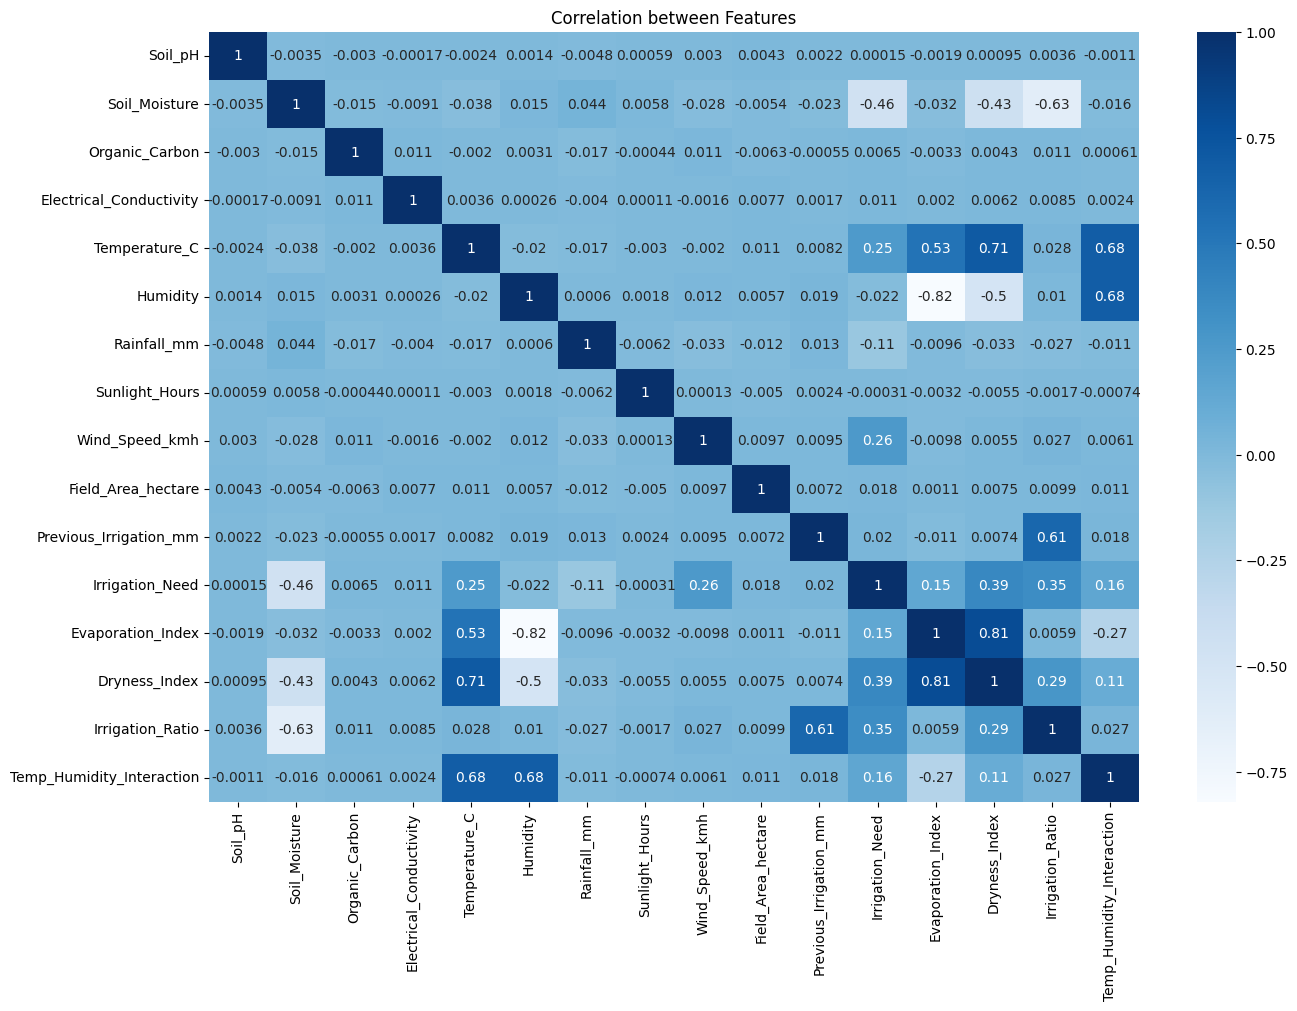

In [37]:
plt.figure(figsize=(15,10))
sns.heatmap(df_train.corr(numeric_only=True),annot=True, cmap='Blues')
plt.title("Correlation between Features")
plt.show()

In [38]:
x = df_train.drop(['Irrigation_Need'], axis=1)
y = df_train['Irrigation_Need']
y = to_categorical(y)

## Encoding

In [39]:
ordinal_encoder = OrdinalEncoder()
cat_cols=list(x.select_dtypes( include=['object']).columns)
encoder=OrdinalEncoder()
x[cat_cols]=encoder.fit_transform(x[cat_cols])
df_test[cat_cols]=encoder.transform(df_test[cat_cols])

In [40]:
len(x.columns), len(df_test.columns)

(23, 23)

## Scaling

In [41]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x= sc.fit_transform(x)
df_test=sc.transform(df_test)

## Deep Learning Model

In [42]:
model = Sequential([
    Dense(232, activation='relu', input_shape=(x.shape[1],)),

    Dense(164, activation='relu'),

    Dropout(0.2),
    Dense(32, activation='relu'),

    Dense(3, activation='softmax') ])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 232)            │         5,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 164)            │        38,212 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 164)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         5,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,159 (192.03 KB)

 Trainable params: 49,159 (192.03 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(monitor='val_loss', patience=5)

checkpoints = ModelCheckpoint("best_model.keras",
                              monitor="val_loss",
                              save_best_only=True)

model.fit(x, y, epochs=50,
          validation_split=0.1, batch_size=100,
          callbacks=[early_stopping,checkpoints])

Epoch 1/50
5670/5670 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.9833 - loss: 0.0622 - val_accuracy: 0.9812 - val_loss: 0.0708
Epoch 2/50
5670/5670 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.9833 - loss: 0.0620 - val_accuracy: 0.9820 - val_loss: 0.0699
Epoch 3/50
5670/5670 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - accuracy: 0.9833 - loss: 0.0618 - val_accuracy: 0.9818 - val_loss: 0.0695
Epoch 4/50
5670/5670 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.9834 - loss: 0.0616 - val_accuracy: 0.9821 - val_loss: 0.0702
Epoch 5/50
5670/5670 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.9834 - loss: 0.0613 - val_accuracy: 0.9817 - val_loss: 0.0717
Epoch 6/50
5670/5670 ━━━━━━━━━━━━━━━━━━━━ 42s 5ms/step - accuracy: 0.9834 - loss: 0.0611 - val_accuracy: 0.9818 - val_loss: 0.0710
Epoch 7/50
5670/5670 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.9835 - loss: 0.0609 - val_accuracy: 0.9820 - val_loss: 0.0708
Epoch 8/50
5670/5670 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - accuracy: 0.9834 - loss: 0

In [46]:
model.evaluate(x, y)

19688/19688 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - accuracy: 0.9845 - loss: 0.0569


[0.05689776688814163, 0.9845206141471863]

In [47]:
model.save('model.h5')

In [48]:
from sklearn.metrics import balanced_accuracy_score
pred_train = model.predict(x)
balanced_accuracy_score(y.argmax(axis=1), pred_train.argmax(axis=1))

19688/19688 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step


np.float64(0.9611529404006083)

# sub

In [49]:
y_pred = model.predict(df_test)
y_pred = y_pred.argmax(axis=1)
y_pred

8438/8438 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


array([0, 0, 0, ..., 1, 0, 1])

In [52]:
sub['Irrigation_Need'] = y_pred
sub['Irrigation_Need'] = sub['Irrigation_Need'].map({0:"Low", 1: "Medium", 2:"High"})
sub

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
...,...,...
269995,899995,Medium
269996,899996,Low
269997,899997,Medium
269998,899998,Low


In [58]:
from google.colab import files
sub.to_csv("sub_1.csv", index=False)

In [59]:
files.download("sub_1.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>